Covers all visualization for the data 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

netid = 'pshu'
summary = pd.read_csv(netid + '_project_summary.csv', sep=';')
summary['month'] = pd.to_datetime(summary['time'], unit='s').dt.to_period('M')

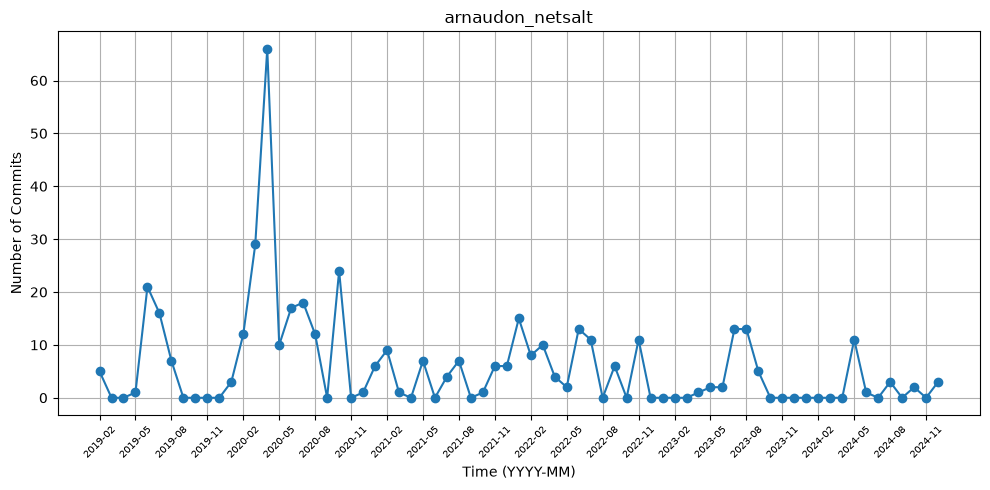

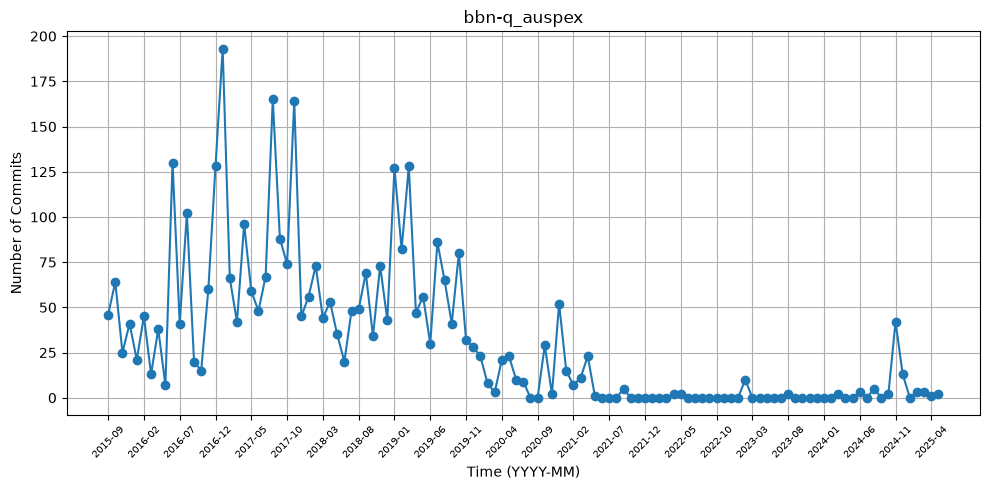

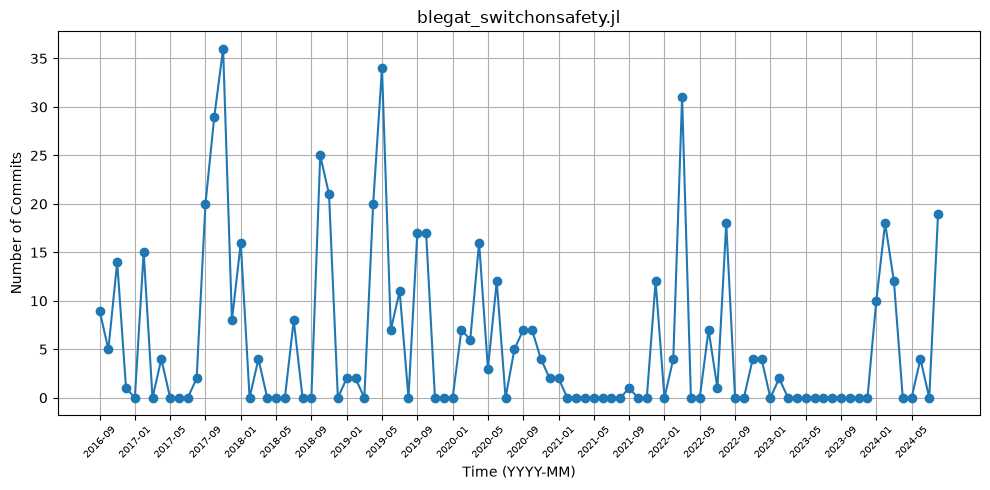

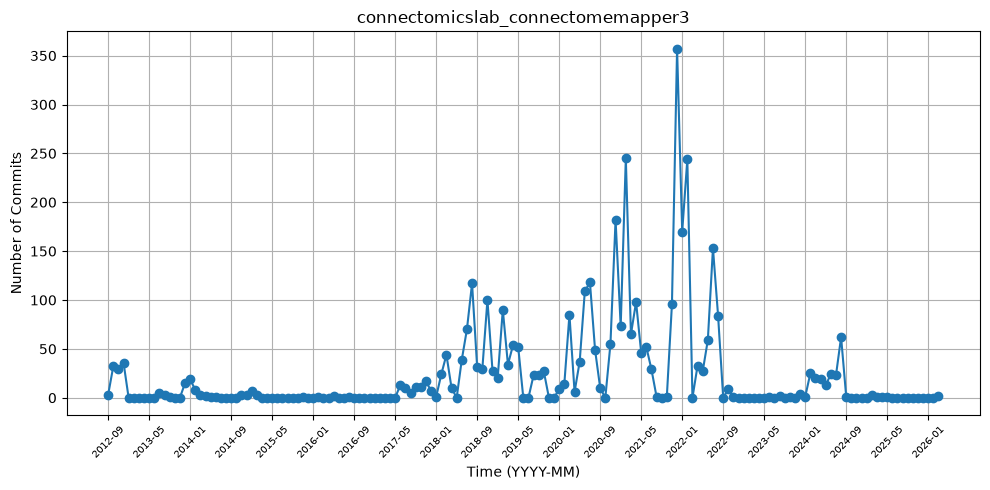

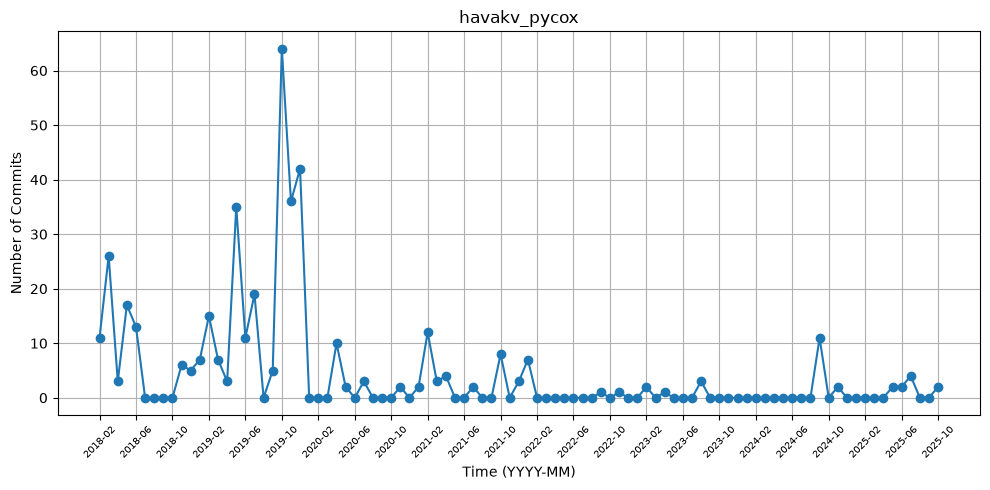

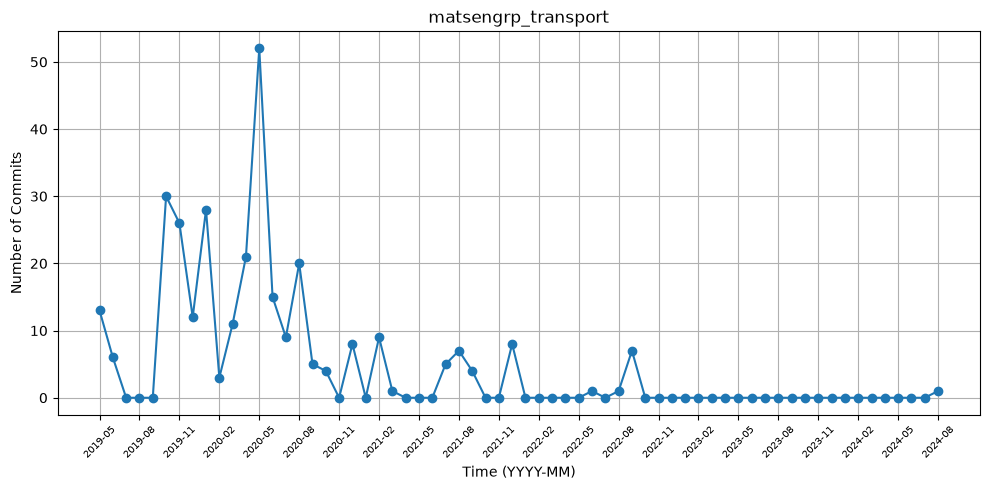

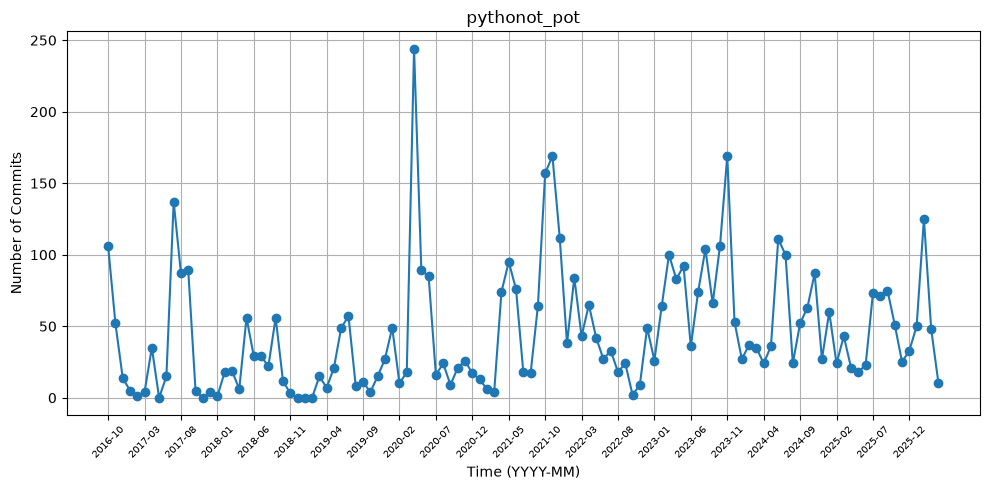

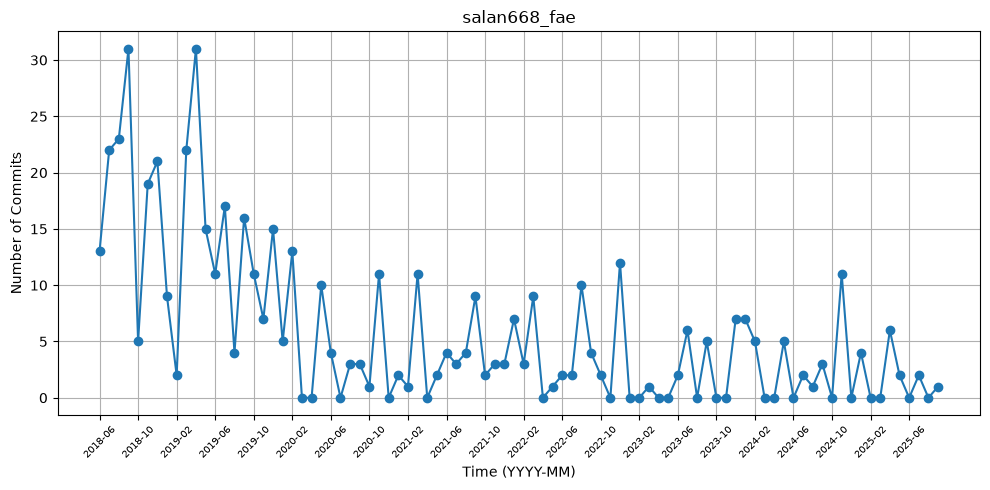

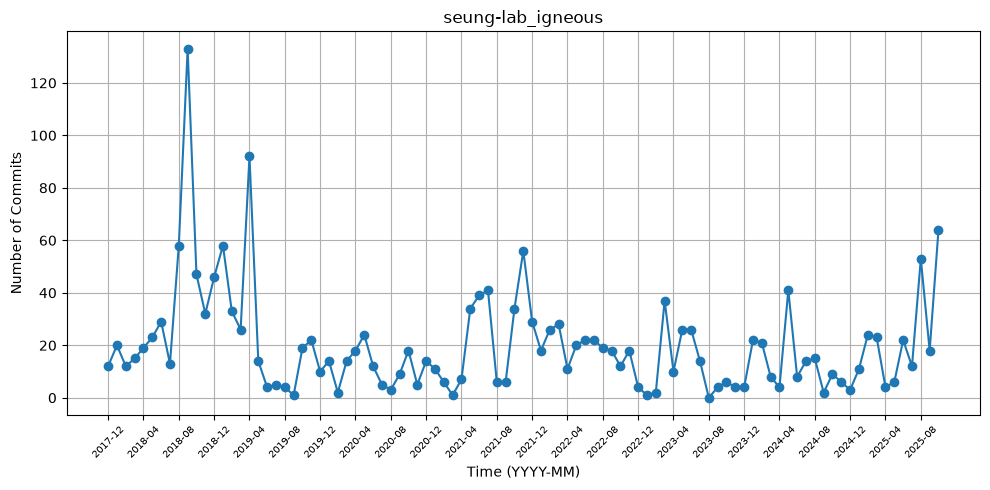

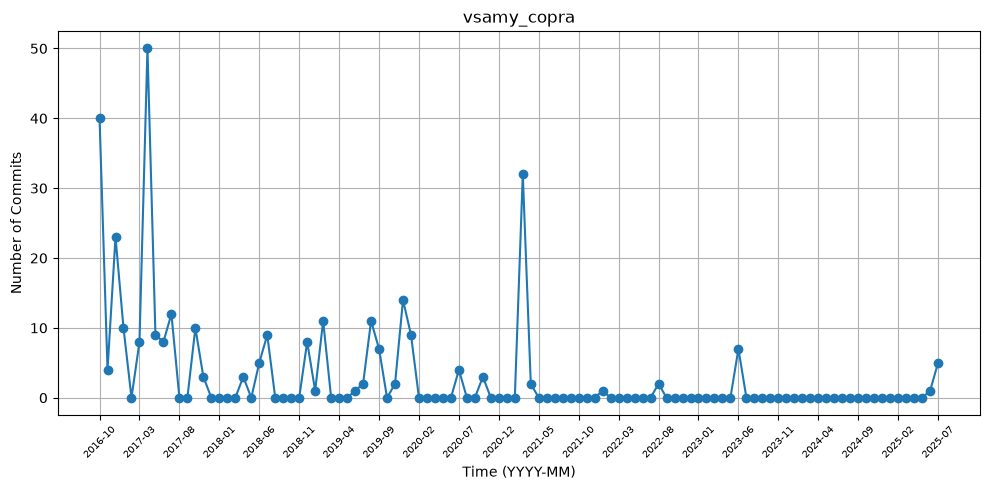

,project,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,arnaudon_netsalt,2023-10,2024-04,7,20,3
1,bbn-q_auspex,2022-06,2023-01,8,88,5
2,blegat_switchonsafety.jl,2023-03,2023-12,10,63,5
3,connectomicslab_connectomemapper3,2016-09,2017-05,9,3610,7
4,havakv_pycox,2023-09,2024-08,12,23,7
5,matsengrp_transport,2022-10,2024-07,22,1,4
6,pythonot_pot,2018-12,2019-02,3,4407,1
7,salan668_fae,2020-03,2020-04,2,198,0
8,seung-lab_igneous,2023-08,2023-08,1,408,0
9,vsamy_copra,2023-07,2025-05,23,6,9


In [2]:
rows = []

for prj, g in summary.groupby('project_wocid'):
    counts = g.groupby('month').size()
    months = pd.period_range(counts.index.min(), counts.index.max(), freq='M')
    counts = counts.reindex(months, fill_value=0)

    # monthly csv + plot
    out = pd.DataFrame({'Month': months.strftime('%Y-%m'), '#Commits': counts.values})
    out.to_csv(netid + '_commits_timeseries_' + prj + '.csv', index=False, sep=';')

    plt.figure(figsize=(10, 5))
    plt.plot(out['Month'], out['#Commits'], marker='o', linestyle='-')
    plt.xlabel('Time (YYYY-MM)')
    plt.ylabel('Number of Commits')
    plt.title(prj)
    plt.grid(True)
    step = max(1, len(out) // 20)
    plt.xticks(range(0, len(out), step), out['Month'][::step], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig(netid + '_timeseries_' + prj + '.png', dpi=300)
    plt.show()
    plt.close()

    # longest zero run
    run, best_len, best_start, ngaps = 0, 0, 0, 0
    for i, n in enumerate(counts.values):
        if n == 0:
            run += 1
            if run > best_len:
                best_len = run
                best_start = i - run + 1
            # gaps 3+ months
            if run == 3:
                ngaps += 1
        else:
            run = 0

    if best_len > 0:
        gs = months[best_start].strftime('%Y-%m')
        ge = months[best_start + best_len - 1].strftime('%Y-%m')
        after = counts.values[best_start + best_len:].sum()
    else:
        gs, ge, after = None, None, counts.sum()

    rows.append([prj, gs, ge, best_len, after, ngaps])

gaps = pd.DataFrame(rows, columns=['project', 'LongestGapStart (YYYY-MM)', 'LongestGapEnd (YYYY-MM)',
                                   'LongestGapLength', 'NumCommitsAfterLastGap', 'NumberOfGapsInTimeline'])
gaps

In [3]:
patterns = {
    'arnaudon_netsalt': 'declining',
    'bbn-q_auspex': 'declining',
    'blegat_switchonsafety.jl': 'irregular',
    'connectomicslab_connectomemapper3': 'declining',
    'havakv_pycox': 'declining',
    'matsengrp_transport': 'declining',
    'pythonot_pot': 'irregular',
    'salan668_fae': 'declining',
    'seung-lab_igneous': 'U-shaped',
    'vsamy_copra': 'declining',
}

In [4]:
# part 2 csv
stats = pd.read_csv(netid + '_project_stats.csv', sep=';').iloc[:, :8]
stats = stats.merge(gaps, on='project')
stats['ActivityPattern'] = stats.project.map(patterns)
stats.to_csv(netid + '_project_stats.csv', index=False, sep=';')
stats

,project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,arnaudon_netsalt,425,15,2019-02-18,2024-12-05,9,4,2026-08-14,2023-10,2024-04,7,20,3,declining
1,bbn-q_auspex,3636,75,2015-09-11,2025-05-30,34,15,2026-06-18,2022-06,2023-01,8,88,5,declining
2,blegat_switchonsafety.jl,545,9,2016-09-25,2024-08-22,24,2,2024-08-14,2023-03,2023-12,10,63,5,irregular
3,connectomicslab_connectomemapper3,3789,30,2012-09-20,2026-03-20,87,31,2025-02-04,2016-09,2017-05,9,3610,7,declining
4,havakv_pycox,414,38,2018-02-12,2025-10-30,996,203,2024-09-04,2023-09,2024-08,12,23,7,declining
5,matsengrp_transport,307,10,2019-05-14,2024-08-24,4,0,2024-08-24,2022-10,2024-07,22,1,4,declining
6,pythonot_pot,5212,190,2016-10-20,2026-04-10,2848,569,2026-10-05,2018-12,2019-02,3,4407,1,irregular
7,salan668_fae,510,30,2018-06-11,2025-09-01,172,50,2026-09-26,2020-03,2020-04,2,198,0,declining
8,seung-lab_igneous,1897,37,2017-12-15,2025-10-22,69,24,2026-09-30,2023-08,2023-08,1,408,0,U-shaped
9,vsamy_copra,317,14,2016-10-10,2025-07-23,43,10,2026-07-04,2023-07,2025-05,23,6,9,declining


# Interpretation

**arnaudon_netsalt** declining | (3 gaps of 3+ months)

Higher activity at first with a spike in commits but then slowly falls off.

**bbn-q_auspex** declining | (5 gaps of 3+ months)

High activity at the beginning, then drops to 0 commits for a lot of the time series. 

**blegat_switchonsafety.jl** irregular | (5 gaps of 3+ months)

The average seems to dip a little so it could be "declining" but the random spikes make it hard to say anything arguably. 

**connectomicslab_connectomemapper3** declining | (7 gaps of 3+ months)

Commit number spikes midway through the graph and then drops. Due to the dropoff with 0 commits in recent history, it's declining.

**havakv_pycox** declining | (7 gaps of 3+ months)

A lot of activity at the beginning and then nothing afterwards. 

**matsengrp_transport** declining | (4 gaps of 3+ months)

Same as the prior, a lot of beginning activity but dropped to zero and rarely has any commits now. 

**pythonot_pot** irregular | (1 gap of 3+ months)

Average activity could be increasing or decreasing depending on interpretation, but the random spikes make it lean irregular.

**salan668_fae** declining | (0 gaps of 3+ months)

Repo is still active but declines over time. 

**seung-lab_igneous** U-shaped | (0 gaps of 3+ months)

The beginning commits are higher with a dip in the middle. Recently there seems to be an upward trend of more commits. 

**vsamy_copra** declining | (9 gaps of 3+ months)

Initially high activity but declines to dead with a few random commits. 

# Part 3

In [5]:
stats = pd.read_csv(netid + '_project_stats.csv', sep=';')
summary = summary.sort_values('time', kind='stable')

# 10 before, 10 after gap
parts = []
for i in range(len(stats)):
    gs = pd.Period(stats['LongestGapStart (YYYY-MM)'][i], 'M')
    ge = pd.Period(stats['LongestGapEnd (YYYY-MM)'][i], 'M')
    g = summary[summary.project_wocid == stats.project[i]]
    pre = g[g.month < gs].tail(10).copy()
    post = g[g.month > ge].head(10).copy()
    pre['pre_post'] = 'pre'
    post['pre_post'] = 'post'
    parts += [pre, post]

gap_commits = pd.concat(parts)[['pre_post', 'project_wocid', 'commit_sha1', 'author', 'time', 'message']]
gap_commits.columns = ['pre_post', 'project', 'commit', 'author', 'time', 'message']
gap_commits.to_csv(netid + '_project_gap_commits.csv', index=False, sep=';')
gap_commits.groupby(['project', 'pre_post']).size()

project                            pre_post
arnaudon_netsalt                   post        10
                                   pre         10
bbn-q_auspex                       post        10
                                   pre         10
blegat_switchonsafety.jl           post        10
                                   pre         10
connectomicslab_connectomemapper3  post        10
                                   pre         10
havakv_pycox                       post        10
                                   pre         10
matsengrp_transport                post         1
                                   pre         10
pythonot_pot                       post        10
                                   pre         10
salan668_fae                       post        10
                                   pre         10
seung-lab_igneous                  post        10
                                   pre         10
vsamy_copra                        post         6
      

In [6]:
prj = 'arnaudon_netsalt'
g = gap_commits[gap_commits.project == prj]
for i in range(len(g)):
    print(g.pre_post.iloc[i], pd.to_datetime(g.time.iloc[i], unit='s').date(), g.author.iloc[i], g.message.iloc[i].strip().split('\n')[0][:100])

pre 2023-08-18 arnaudon <alexis.arnaudon@epfl.ch> fix
pre 2023-08-18 Alexis Arnaudon <alexis.arnaudon@epfl.ch> Feat: Added node loss (#23)
pre 2023-08-18 arnaudon <alexis.arnaudon@epfl.ch> fix
pre 2023-08-29 arnaudon <alexis.arnaudon@epfl.ch> more
pre 2023-08-29 arnaudon <alexis.arnaudon@epfl.ch> lint
pre 2023-09-05 arnaudon <alexis.arnaudon@epfl.ch> more
pre 2023-09-11 arnaudon <alexis.arnaudon@epfl.ch> more
pre 2023-09-14 arnaudon <alexis.arnaudon@epfl.ch> more
pre 2023-09-15 arnaudon <alexis.arnaudon@epfl.ch> more
pre 2023-09-15 Alexis Arnaudon <alexis.arnaudon@epfl.ch> Merge 0c45720cc6d011aefd8a1e6ff9d526662f00e970 into 3c48f14ddcaafcf8ff62a63d221df5c8334bf944
post 2024-05-16 arnaudon <alexis.arnaudon@epfl.ch> tmp
post 2024-05-16 arnaudon <alexis.arnaudon@epfl.ch> Fix: Assign positions for unordered nodes
post 2024-05-16 arnaudon <alexis.arnaudon@epfl.ch> fix
post 2024-05-16 arnaudon <alexis.arnaudon@epfl.ch> fix test
post 2024-05-16 arnaudon <alexis.arnaudon@epfl.ch> fix
post 2024

In [7]:
before_themes = {
    'arnaudon_netsalt': 'Other:Bug fixes',
    'bbn-q_auspex': 'Bug fixes:Other',
    'blegat_switchonsafety.jl': 'Documentation updates:Automated bot contributions',
    'connectomicslab_connectomemapper3': 'Bug fixes:Feature development',
    'havakv_pycox': 'Bug fixes:Dependency updates',
    'matsengrp_transport': 'Documentation updates:Feature development',
    'pythonot_pot': 'Bug fixes:Other',
    'salan668_fae': 'Feature development:Bug fixes',
    'seung-lab_igneous': 'Bug fixes:Feature development',
    'vsamy_copra': 'Other:Dependency updates',
}

after_themes = {
    'arnaudon_netsalt': 'Bug fixes:Other',
    'bbn-q_auspex': 'Bug fixes:Other',
    'blegat_switchonsafety.jl': 'Dependency updates:Automated bot contributions',
    'connectomicslab_connectomemapper3': 'Feature development:Other',
    'havakv_pycox': 'Dependency updates:Release',
    'matsengrp_transport': 'Documentation updates',
    'pythonot_pot': 'Documentation updates:Bug fixes',
    'salan668_fae': 'Feature development:Release',
    'seung-lab_igneous': 'Bug fixes:Release',
    'vsamy_copra': 'Other:Dependency updates',
}

# Part 4

In [8]:
prj = 'arnaudon_netsalt'
recent = summary[summary.project_wocid == prj].sort_values('time').tail(10)
for i in range(len(recent)):
    print(pd.to_datetime(recent.time.iloc[i], unit='s').date(), recent.author.iloc[i], recent.message.iloc[i].strip().split('\n')[0][:100])

2024-05-16 Alexis Arnaudon <alexis.arnaudon@epfl.ch> Fix: Assign positions for unordered nodes (#30)
2024-06-25 Alexis Arnaudon <alexis.arnaudon@epfl.ch> Merge 944a9d2aa24d223e302773ec60f3db44db3ab468 into fa0a2aed237f134f80aa88dd6a8afb5f7d0707ca
2024-08-02 arnaudon <alexis.arnaudon@epfl.ch> more
2024-08-02 arnaudon <alexis.arnaudon@epfl.ch> open example
2024-08-07 arnaudon <alexis.arnaudon@epfl.ch> more
2024-10-25 saxedh <d.saxena@imperial.ac.uk> Updated examples with custom index on edges
2024-10-30 arnaudon <alexis.arnaudon@epfl.ch> more
2024-12-05 paul019 <39464035+paul019@users.noreply.github.com> Switch two lines, thereby removing the problem
2024-12-05 Paul Obernolte <39464035+paul019@users.noreply.github.com> Switch two lines, thereby removing the problem (#33)
2024-12-05 Alexis Arnaudon <alexis.arnaudon@epfl.ch> Merge 29895b6a63b525147b902b18607bca168c7c1e5e into 7729c76caf991c3dd5bc2e584205fefe3ca14dcb


In [9]:
HypothesizedGapReason = {
    'arnaudon_netsalt': 'Maintainer paused after a big code cleanup. Nobody else was really contributing, and no issues or PRs were waiting during the gap.',
    'bbn-q_auspex': 'Small team that only seems to work on it when the hardware needs fixes. Activity was already low before the gap and no issues or PRs were opened during it.',
    'blegat_switchonsafety.jl': 'Project in maintenance mode with one maintainer. Commits before the gap were mostly docs and bots, and no issues or PRs were opened during it.',
    'connectomicslab_connectomemapper3': "Handed off and rewritten by a new maintainer. The old developer's commits stop and the next ones describe a major rewrite.",
    'havakv_pycox': 'Original maintainer went quiet while other people patched things and issues piled up unanswered.',
    'matsengrp_transport': 'Research code for a paper that was finished. The README now says it is no longer being developed and points to a newer package.',
    'pythonot_pot': 'Short break after a release and some cleanup. The project is active otherwise and the issues around the gap were closed, so it looks like a normal quiet stretch.',
    'salan668_fae': 'N/A active Project',
    'seung-lab_igneous': 'N/A active Project',
    'vsamy_copra': 'Library seems finished and stable. The last commits before the gap were a release and small upkeep, and no issues or PRs were opened during the gap.',
}

HasRecovered = {
    'arnaudon_netsalt': 'Yes',
    'bbn-q_auspex': 'Yes',
    'blegat_switchonsafety.jl': 'Yes',
    'connectomicslab_connectomemapper3': 'Yes',
    'havakv_pycox': 'Yes',
    'matsengrp_transport': 'No',
    'pythonot_pot': 'Yes',
    'salan668_fae': 'N/A',
    'seung-lab_igneous': 'N/A',
    'vsamy_copra': 'Yes',
}

WhyRecovered = {
    'arnaudon_netsalt': 'A user reported a bug and the maintainer fixed it right away.',
    'bbn-q_auspex': 'Fixes for hardware compatibility problems.',
    'blegat_switchonsafety.jl': 'Updates to keep the project working with newer tools and versions.',
    'connectomicslab_connectomemapper3': 'A new development phase with the rewrite.',
    'havakv_pycox': 'Install and dependency problems. The maintainer came back to update versions and make a new release.',
    'matsengrp_transport': 'N/A (only one README edit pointing to the newer package)',
    'pythonot_pot': 'A bug report that got fixed quickly, followed by docs and new features.',
    'salan668_fae': 'N/A',
    'seung-lab_igneous': 'N/A',
    'vsamy_copra': 'Updates to keep it working on newer systems and a new release.',
}

WhoRecovered = {
    'arnaudon_netsalt': 'Mostly the same maintainer, plus a couple of outside contributors.',
    'bbn-q_auspex': 'The same developer.',
    'blegat_switchonsafety.jl': 'Mostly the same maintainer and bots, plus one new contributor.',
    'connectomicslab_connectomemapper3': 'A new person took over. None of the earlier authors came back.',
    'havakv_pycox': 'The original maintainer returned, along with some outside contributors.',
    'matsengrp_transport': 'N/A (the only commit is from an existing author)',
    'pythonot_pot': 'The same main maintainers, plus one new contributor.',
    'salan668_fae': 'N/A',
    'seung-lab_igneous': 'N/A',
    'vsamy_copra': "New maintainers. The earlier maintainer doesn't show up after the gap.",
}

RecentThemes = {
    'arnaudon_netsalt': 'Bug fixes:Other',
    'bbn-q_auspex': 'Bug fixes:Automated bot contributions',
    'blegat_switchonsafety.jl': 'Automated bot contributions:Dependency updates',
    'connectomicslab_connectomemapper3': 'Bug fixes:Automated bot contributions',
    'havakv_pycox': 'Bug fixes:Dependency updates',
    'matsengrp_transport': 'Documentation updates:Feature development',
    'pythonot_pot': 'Feature development:Documentation updates',
    'salan668_fae': 'Release:Bug fixes',
    'seung-lab_igneous': 'Bug fixes:Other',
    'vsamy_copra': 'Other:Dependency updates',
}

Notes = {
    'arnaudon_netsalt': 'Declining but still maintained by one person in small bursts. The gap was easy to explain: a cleanup, then quiet until a user reported a bug. Still active.',
    'bbn-q_auspex': 'Declining. Busy early and mostly quiet since, with short bursts of fixes. The gap was hard to explain because there is little to go on, so the reason is a guess. It recovered a little with the same developer.',
    'blegat_switchonsafety.jl': 'Irregular bursts from one maintainer plus bots. The gap is probably maintenance mode, and it came back for updates. Inactive now.',
    'connectomicslab_connectomemapper3': 'Quiet early on, a big peak in the middle, and fading now. The gap was a handoff to a new maintainer who rewrote it, not an abandonment. Inactive by the 6 month rule.',
    'havakv_pycox': 'Declining after an early peak. The gap matches unanswered issues, and it ended when the original maintainer updated things and made a release. Inactive now.',
    'matsengrp_transport': 'Declining to zero. Easy to explain since the README says it is no longer developed and points to a replacement. Inactive.',
    'pythonot_pot': 'Rising overall with big irregular spikes. The only long gap was a short break after a release, and it picked back up after a bug report. Very active.',
    'salan668_fae': 'Declining from a strong start but still active, with no real gap. Different people were committing before and after the short break. Active.',
    'seung-lab_igneous': 'Active the whole time with no real gap, mostly from one maintainer. Active.',
    'vsamy_copra': 'Declining to almost nothing, with very few commits after the gap. Looks like a finished library that got a small update for newer systems. Active by the rule.',
}

In [10]:
stats['BeforeThemes'] = stats.project.map(before_themes)
stats['AfterThemes'] = stats.project.map(after_themes)
stats['HypothesizedGapReason'] = stats.project.map(HypothesizedGapReason)
stats['HasRecovered'] = stats.project.map(HasRecovered)
stats['WhyRecovered'] = stats.project.map(WhyRecovered)
stats['WhoRecovered'] = stats.project.map(WhoRecovered)
# inactive if last commit before 2025-04
stats['Currentstatus'] = ['Inactive' if x < '2025-04-01' else 'Active' for x in stats.lastGHCommitDate]
stats['RecentThemes'] = stats.project.map(RecentThemes)
stats['Notes'] = stats.project.map(Notes)
stats.to_csv(netid + '_project_stats.csv', index=False, sep=';')
stats

,project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),...,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
0,arnaudon_netsalt,425,15,2019-02-18,2024-12-05,9,4,2026-08-14,2023-10,2024-04,...,declining,Other:Bug fixes,Bug fixes:Other,Maintainer paused after a big code cleanup. No...,Yes,A user reported a bug and the maintainer fixed...,"Mostly the same maintainer, plus a couple of o...",Active,Bug fixes:Other,Declining but still maintained by one person i...
1,bbn-q_auspex,3636,75,2015-09-11,2025-05-30,34,15,2026-06-18,2022-06,2023-01,...,declining,Bug fixes:Other,Bug fixes:Other,Small team that only seems to work on it when ...,Yes,Fixes for hardware compatibility problems.,The same developer.,Active,Bug fixes:Automated bot contributions,"Declining. Busy early and mostly quiet since, ..."
2,blegat_switchonsafety.jl,545,9,2016-09-25,2024-08-22,24,2,2024-08-14,2023-03,2023-12,...,irregular,Documentation updates:Automated bot contributions,Dependency updates:Automated bot contributions,Project in maintenance mode with one maintaine...,Yes,Updates to keep the project working with newer...,"Mostly the same maintainer and bots, plus one ...",Inactive,Automated bot contributions:Dependency updates,Irregular bursts from one maintainer plus bots...
3,connectomicslab_connectomemapper3,3789,30,2012-09-20,2026-03-20,87,31,2025-02-04,2016-09,2017-05,...,declining,Bug fixes:Feature development,Feature development:Other,Handed off and rewritten by a new maintainer. ...,Yes,A new development phase with the rewrite.,A new person took over. None of the earlier au...,Inactive,Bug fixes:Automated bot contributions,"Quiet early on, a big peak in the middle, and ..."
4,havakv_pycox,414,38,2018-02-12,2025-10-30,996,203,2024-09-04,2023-09,2024-08,...,declining,Bug fixes:Dependency updates,Dependency updates:Release,Original maintainer went quiet while other peo...,Yes,Install and dependency problems. The maintaine...,"The original maintainer returned, along with s...",Inactive,Bug fixes:Dependency updates,Declining after an early peak. The gap matches...
5,matsengrp_transport,307,10,2019-05-14,2024-08-24,4,0,2024-08-24,2022-10,2024-07,...,declining,Documentation updates:Feature development,Documentation updates,Research code for a paper that was finished. T...,No,N/A (only one README edit pointing to the newe...,N/A (the only commit is from an existing author),Inactive,Documentation updates:Feature development,Declining to zero. Easy to explain since the R...
6,pythonot_pot,5212,190,2016-10-20,2026-04-10,2848,569,2026-10-05,2018-12,2019-02,...,irregular,Bug fixes:Other,Documentation updates:Bug fixes,Short break after a release and some cleanup. ...,Yes,"A bug report that got fixed quickly, followed ...","The same main maintainers, plus one new contri...",Active,Feature development:Documentation updates,Rising overall with big irregular spikes. The ...
7,salan668_fae,510,30,2018-06-11,2025-09-01,172,50,2026-09-26,2020-03,2020-04,...,declining,Feature development:Bug fixes,Feature development:Release,N/A active Project,N/A,N/A,N/A,Active,Release:Bug fixes,Declining from a strong start but still active...
8,seung-lab_igneous,1897,37,2017-12-15,2025-10-22,69,24,2026-09-30,2023-08,2023-08,...,U-shaped,Bug fixes:Feature development,Bug fixes:Release,N/A active Project,N/A,N/A,N/A,Active,Bug fixes:Other,"Active the whole time with no real gap, mostly..."
9,vsamy_copra,317,14,2016-10-10,2025-07-23,43,10,2026-07-04,2023-07,2025-05,...,declining,Other:Dependency updates,Other:Dependency updates,Library seems finished and stable. The last co...,Yes,Updates to keep it working on newer systems an...,New maintainers. The earlier maintainer doesn'...,Active,Other:Dependency updates,"Declining to almost nothing, with very few com..."
